In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split , StratifiedKFold,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,MinMaxScaler,FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score
from sklearn.ensemble import VotingClassifier,StackingClassifier,RandomForestClassifier,GradientBoostingClassifier,ExtraTreesClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression



In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

In [3]:
train.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [5]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
train.nunique()

id                  594194
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1921
TotalCharges         31910
Churn                    2
dtype: int64

In [7]:
for col in train.columns:
    print("-"*50)
    print(f"{col}:{train[col].nunique()}")
    if train[col].nunique()<10:
        print(f"Unique Values: {train[col].unique()}")

    

--------------------------------------------------
id:594194
--------------------------------------------------
gender:2
Unique Values: ['Male' 'Female']
--------------------------------------------------
SeniorCitizen:2
Unique Values: [0 1]
--------------------------------------------------
Partner:2
Unique Values: ['Yes' 'No']
--------------------------------------------------
Dependents:2
Unique Values: ['Yes' 'No']
--------------------------------------------------
tenure:72
--------------------------------------------------
PhoneService:2
Unique Values: ['Yes' 'No']
--------------------------------------------------
MultipleLines:3
Unique Values: ['No' 'Yes' 'No phone service']
--------------------------------------------------
InternetService:3
Unique Values: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity:3
Unique Values: ['Yes' 'No' 'No internet service']
--------------------------------------------------
OnlineBackup:3
Unique Values

In [8]:
train=train.drop("id",axis=1)
test=test.drop("id",axis=1)

# EDA

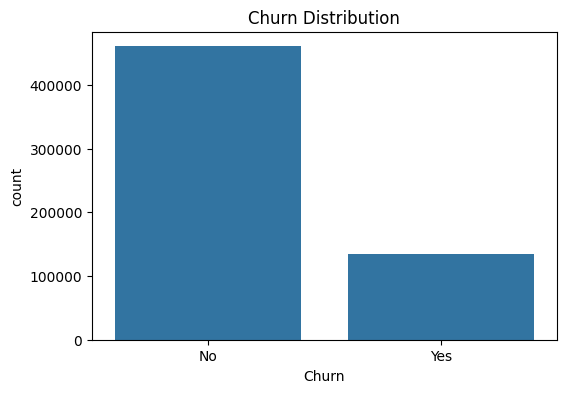

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=train)
plt.title("Churn Distribution")
plt.show()

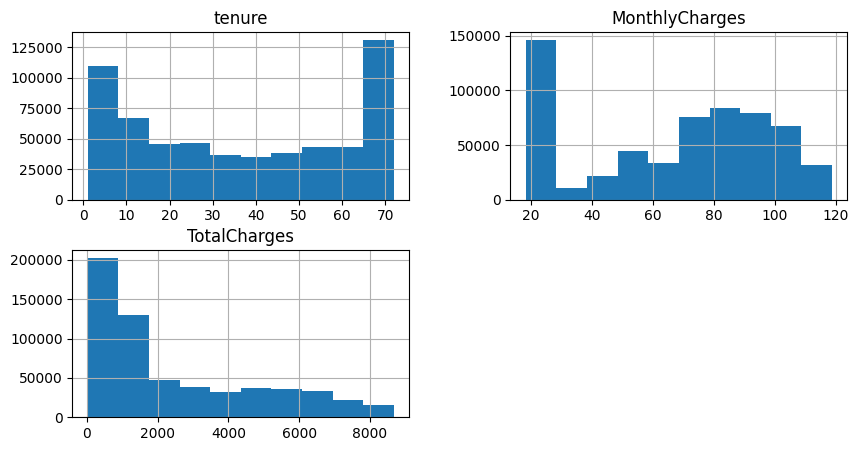

In [10]:
num_col = ['tenure','MonthlyCharges','TotalCharges']

train[num_col].hist(figsize=(10,5))
plt.show()

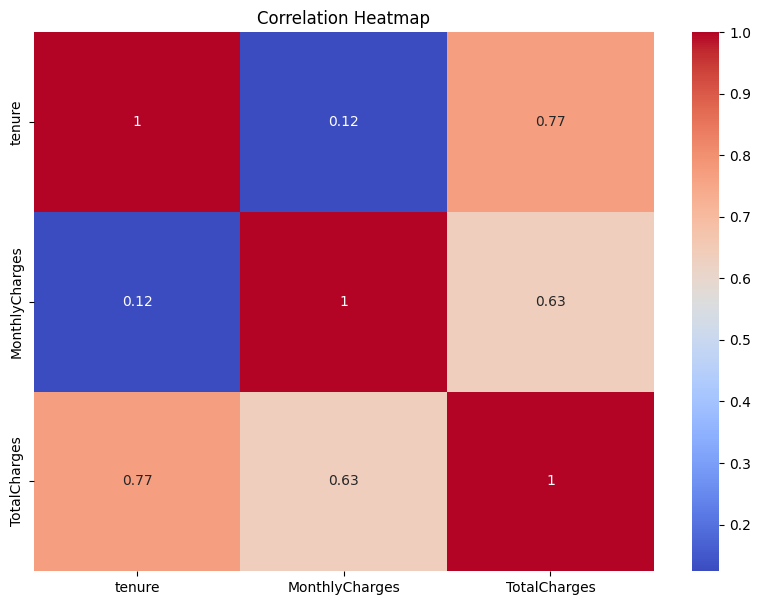

In [11]:
plt.figure(figsize=(10,7))
sns.heatmap(train[num_col].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Preprocessing

In [12]:
train["Churn"]=train["Churn"].map({"No":0,"Yes":1})

In [13]:
x=train.drop("Churn",axis=1)
y=train["Churn"]

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

In [15]:
num_col=[]
cat_col=[]
for col in x_train.columns:
    if x_train[col].nunique()>10:
        num_col.append(col)
    else:
        cat_col.append(col)

#### feature_engineering

In [16]:


def feature_eng(df):
            
    df=df.copy()
            # Handle potential division by zero for tenure
            
    df["avg_spend"] = df['TotalCharges'] / (df["tenure"]+1)
    df['charges_yr'] = (df['MonthlyCharges'] * 12) / (df["tenure"]+1)
            # Additional features
    df["tenure_years"] = df["tenure"] / 12
    df["monthly_to_total_ratio"] = df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)
    df["tenure_monthly_interaction"] = df["tenure"] * df["MonthlyCharges"]
    df["charges_tenure_interaction"] = df["TotalCharges"] * df["tenure"]
    df["charges_monthly_interaction"] = df["TotalCharges"] * df["MonthlyCharges"]
    df["tenure_square"] = df["tenure"]**2
    df["monthly_square"]=df["MonthlyCharges"]**2
    df["total_square"] =df["TotalCharges"]**2
            
            
            
    new_col =["avg_spend",'charges_yr',"tenure_years","monthly_to_total_ratio","tenure_monthly_interaction","charges_tenure_interaction","charges_monthly_interaction","tenure_square","monthly_square","total_square"]
    for col in new_col:
      num_col.append(col)
    return df





#### transformer

In [17]:
trf1=ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("impute", SimpleImputer()),
        ("scale", MinMaxScaler())
    ]), num_col),
    ("cat_pipeline", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat_col)
])

#### Model with Optuna

In [18]:




xgb2 = XGBClassifier(
    n_estimators=1900,
    learning_rate=0.06,
    max_depth=3,
    subsample=0.6,
    colsample_bytree=0.9,
    random_state=42,
    reg_lambda=6,
    eval_metric="auc",
    n_jobs=-1,
)

lgbm1 = LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.06,
    random_state=42,
    reg_lambda=4,
    subsample=0.7,
    colsample_bytree=0.9,
    n_jobs=-1,
    max_depth=4,
    lambda_l2=5,
    lambda_l1=2,
    feature_fraction=0.6,
    bagging_fraction=0.9,
    bagging_freq=5,
    objective="binary",
    verbose=-1,
    metric="auc",
    
)



cat1 = CatBoostClassifier(
    iterations=1800,
    learning_rate=0.06,
    depth=5,
    bagging_temperature=1,
    random_strength=0.2,
    l2_leaf_reg=4,
    eval_metric="AUC",
    subsample=0.7,
    colsample_bylevel=0.9,
    verbose=0,
    random_state=42,
    thread_count=-1
)



lr=LogisticRegression(
        C=1.0,
        random_state=42,
        solver="lbfgs",
        penalty="l2",
        max_iter=1000
)


rf=RandomForestClassifier(
        n_estimators=2000,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
        n_jobs=-1
)

voting2 = VotingClassifier(
        estimators=[
            
            ("lgbm1",lgbm1),
            ("cat1",cat1),
            ("xgb2",xgb2),
       
            
            
            
            
        ],
        voting="soft",
        weights=[1.5,1.3,1],
       
        
    )

stack=StackingClassifier(
            estimators=[
                ("lgbm1",lgbm1),
                ("cat1",cat1),
                ("xgb2",xgb2),
                
            ],
            final_estimator=lr,
            
            n_jobs=-1
)



pipe = ImbPipeline([
        
        ("preprocessing",trf1),
        
        ("model",stack)
])





   



In [19]:
pipe.fit(x_train, y_train)


C:\Users\rosha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for f

In [20]:

pipe_pred = pipe.predict_proba(x_test)[:,1]
roc_auc_score(y_test, pipe_pred)

C:\Users\rosha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9167542091612986

In [21]:
final_pred = pipe.predict_proba(test)[:,1]

C:\Users\rosha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [22]:
final_pred

array([0.05439145, 0.0358034 , 0.06440422, ..., 0.24106084, 0.03605335,
       0.3382958 ], shape=(254655,))

In [23]:
submission=pd.read_csv("sample_submission.csv")

In [24]:
submission

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
...,...,...
254650,848844,0
254651,848845,0
254652,848846,0
254653,848847,0


In [25]:
submission["Churn"]=final_pred

In [26]:
submission

,id,Churn
0,594194,0.054391
1,594195,0.035803
2,594196,0.064404
3,594197,0.036420
4,594198,0.508277
...,...,...
254650,848844,0.035735
254651,848845,0.860940
254652,848846,0.241061
254653,848847,0.036053


In [27]:
submission.to_csv("sub17.csv",index=False)

# Exporting the model

In [28]:
import pickle as bkl
bkl.dump(pipe,open("model.pkl","wb"))